<a href="https://colab.research.google.com/github/ChristopherDuke545/Renewable-Energy-Technologies-and-Smart-Grids/blob/main/Final_working_code_CWK_vc2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PV + Battery System for a Residential Home: A Consultant's Techno-Economic Assessment

# 📘Introduction

In this project, you will take on the role of an **energy consultant** tasked with assessing the techno-economic feasibility of installing solar PV panels and a battery system for a residential home in the UK. The client wants to understand:

- How much solar energy they can use directly?
- Whether adding a battery improves the system's performance?
- Which pricing scheme (flat or time-of-use) provides better returns?
- What kind of return on investment they can expect?

🔧 This hands-on project will allow you to:
- Explore real-world energy data and perform technical & economic analysis.
- Understand the interaction between PV, battery storage, and energy pricing.
- Use your engineering knowledge in a consultancy-style project relevant to energy transition careers.

🧮 We'll proceed in four parts across three sessions:

| Session | Parts Covered | Focus |
|--------|----------------|-------|
| 1      | Part 0, Part 1 | Data Exploration + PV Modelling |
| 2      | Part 2         | Battery Integration |
| 3      | Part 3         | Energy Economics & Recommendations |



Let's begin!


---

## 📘Part 0: Exploratory Data Analysis

🎯 Objective:
- Load and visualise the residential energy demand and solar irradiance
- Visualise the Time-of-Use (ToU) and flat electricity pricing schemes
- Draw insights to guide design decisions

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# import relevant packages
import pandas as pd
import matplotlib.pyplot as plt

# Load the data (load.csv and ghi.csv files)
# You need to replace '...' with the actual paths to your files, e.g., '/content/drive/MyDrive/load.csv'
load = pd.read_csv('/content/drive/My Drive/Colab Notebooks/full_year_hourly_data.csv', index_col=0, parse_dates=True)
load['average_household_consumption'] = load['average_household_consumption'] / 1000 # Convert Wh to kWh
ghi = pd.read_excel('/content/drive/My Drive/Colab Notebooks/ghi.xlsx', index_col=0, parse_dates=True)

print('load: ', load.head())
print('ghi: ', ghi.head())

load:                    average_household_consumption
local_time                                     
01/01/2019 00:00                       0.481067
01/01/2019 01:00                       0.449133
01/01/2019 02:00                       0.438600
01/01/2019 03:00                       0.260000
01/01/2019 04:00                       0.194067
ghi:                       swgdn
local_time                
2019-01-01 00:00:00    0.0
2019-01-01 01:00:00    0.0
2019-01-01 02:00:00    0.0
2019-01-01 03:00:00    0.0
2019-01-01 04:00:00    0.0


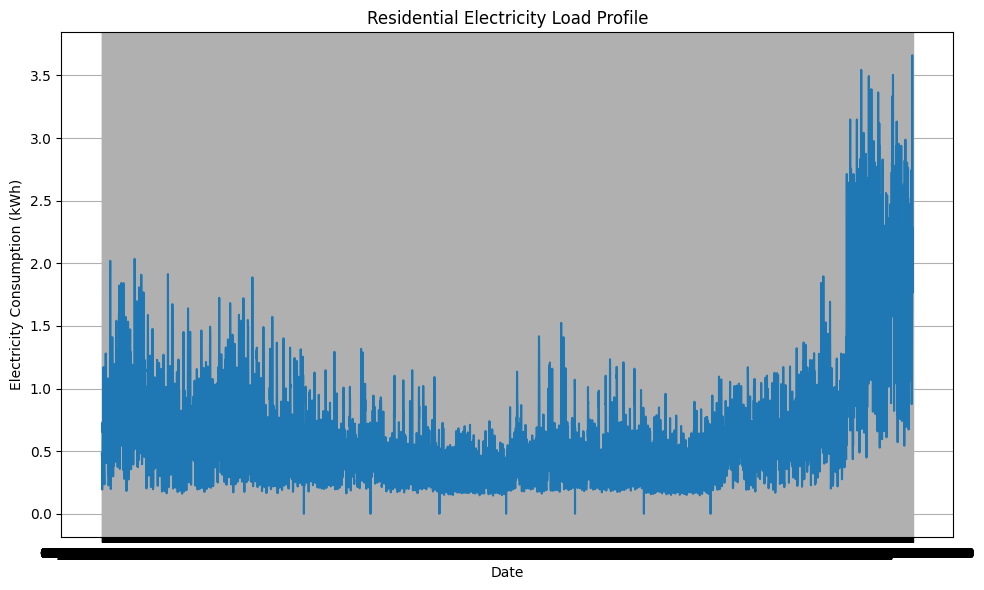

In [ ]:
# Plot Load
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(load['average_household_consumption'])
plt.title("Residential Electricity Load Profile")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

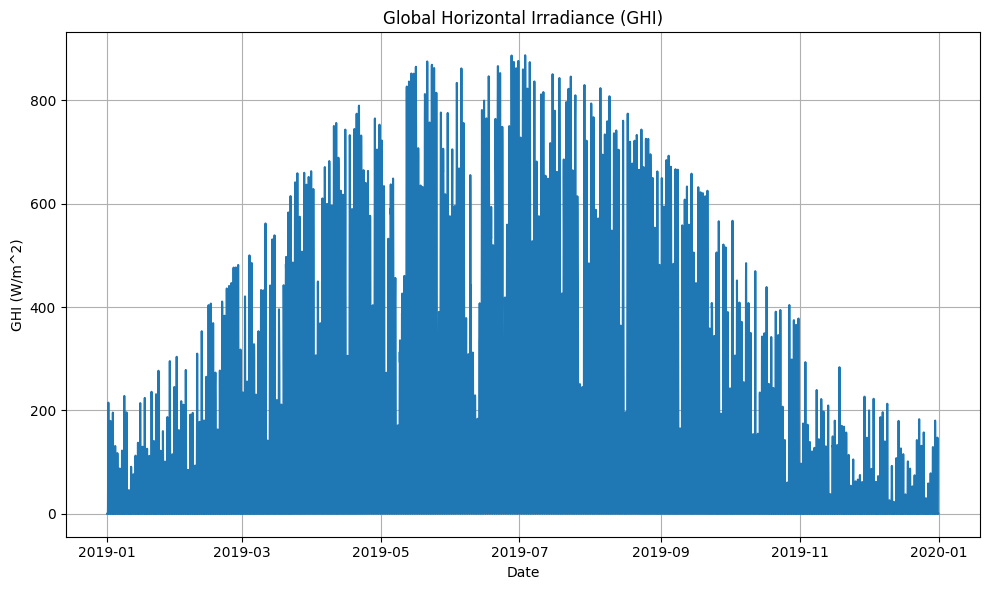

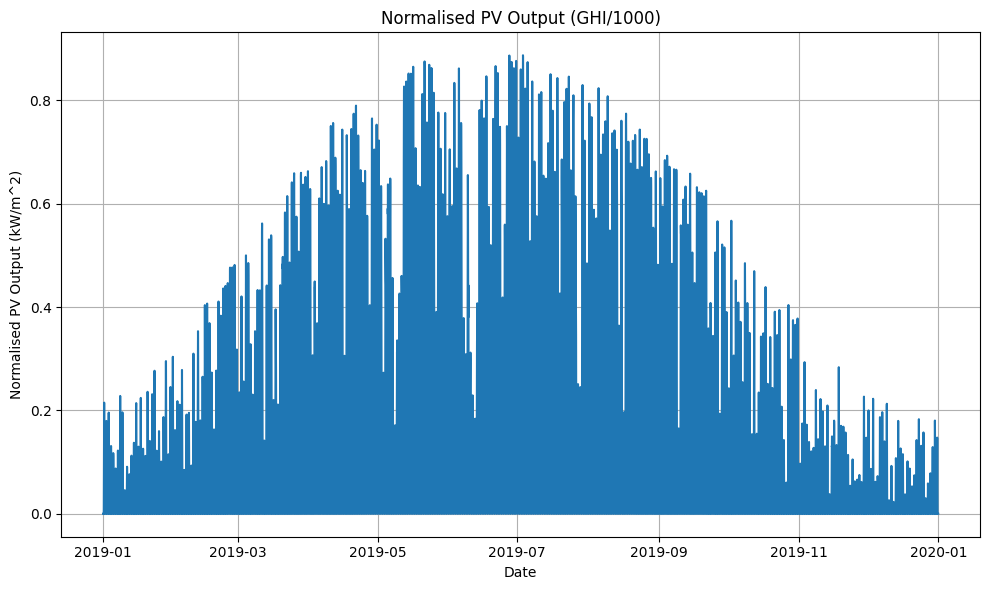

In [ ]:
# Plot GHI
plt.figure(figsize=(10, 6))
plt.plot(ghi['swgdn'])
plt.title("Global Horizontal Irradiance (GHI)")
plt.xlabel("Date")
plt.ylabel("GHI (W/m^2)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Normalised PV output: ghi/1000
# This part is also in the cell, so I'll complete it as well.
plt.figure(figsize=(10, 6))
plt.plot(ghi['swgdn']/1000)
plt.title("Normalised PV Output (GHI/1000)")
plt.xlabel("Date")
plt.ylabel("Normalised PV Output (kW/m^2)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# E7 tariff (Time-of-Use): Off-peak: 15 p/kWh (11pm–7am), Peak: 45 p/kWh
# Create a daily profile for the ToU prices (24 hours)
daily_toup_profile = np.zeros(24)
# Off-peak hours (00:00-07:00 and 23:00)
daily_toup_profile[0:7] = 0.15  # 00:00 to 06:00
daily_toup_profile[23] = 0.15   # 23:00
# Peak hours (07:00-23:00)
daily_toup_profile[7:23] = 0.45 # 07:00 to 22:00

# Repeat the same day vector over the 365 days of the year (8760 hours)
toup = np.tile(daily_toup_profile, 365)

flat_price = 0.30  # 30p/kWh converted to £/kWh

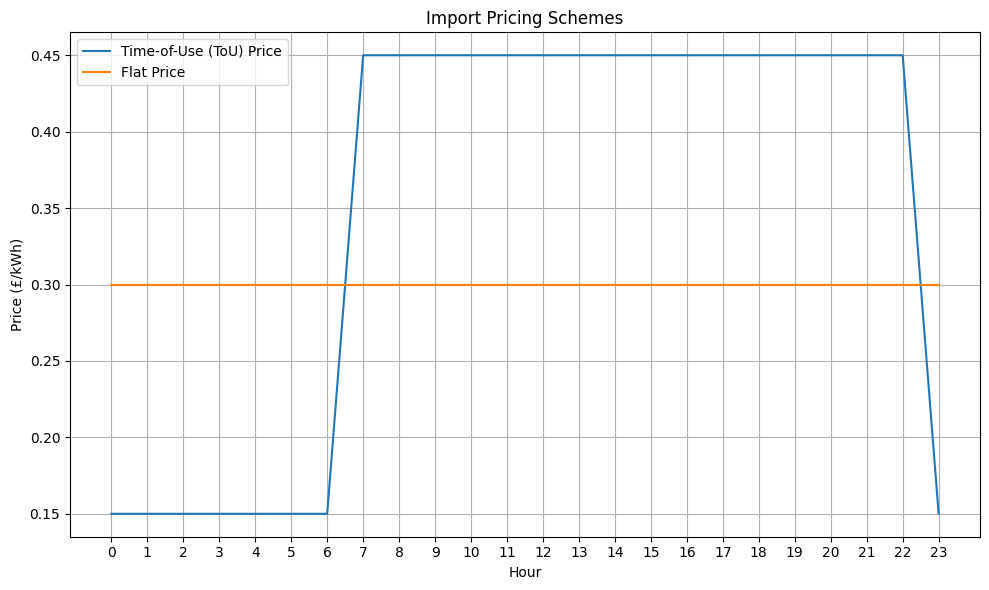

In [ ]:
# Plot Pricing Schemes
plt.figure(figsize=(10, 6))
plt.plot(daily_toup_profile, label='Time-of-Use (ToU) Price')
plt.plot(np.full(24, flat_price), label='Flat Price')
plt.title("Import Pricing Schemes")
plt.xlabel("Hour")
plt.ylabel("Price (£/kWh)")
plt.xticks(np.arange(0, 24, 1)) # Ensure all 24 hours are visible on x-axis
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 📝 Tasks
1. What is the average and peak demand?
2. When is solar potential highest?
3. How do ToU and flat prices differ?
4. What time periods might be best for self-consumption?


---

## 📘Part 1: PV Modelling

### 🎯 Objective:
- Model PV generation based on irradiance and system specs
- Simulate two policy scenarios: no export vs. export with Smart Export Guarantee (SEG)(*)
- Compare results under flat and ToU pricing schemes

(*)The Smart Export Guarantee (SEG) applies to small-scale residential systems (up to 5 MW). It allows homeowners to export surplus electricity to the grid and get paid by a licensed supplier. SEG tariffs are set by suppliers and typical rates for 2024 range between 4 and 15p/kWh.

### Part 1.1. PV model
🧩 **Instructions:**

Modelling a PV asset follow the OOP of python as demonstrated in the structure below:


```
class PV_asset:
     def__init__(self, arguments):
        self.argument1 = argument1
        ....

      def generate():
        return solar power output

```
1. What is the equation that gives PV power output?
2. What are the specific parameters of the PV that impact the PV power output?
3. what other external factors impact this output


In [ ]:
# Define PV Object here
class PV:
    def __init__(self, efficiency, area):
        self.efficiency = efficiency  # PV panel efficiency (e.g., 0.18 for 18%)
        self.area = area              # PV panel area in m^2

    def generate(self, ghi_data): # ghi_data is global horizontal irradiance in W/m^2
        # PV power output = Irradiance * Area * Efficiency
        # Converting W/m^2 to kW/m^2 by dividing by 1000 to get output in kW
        solar_power_output = (ghi_data * self.area * self.efficiency) / 1000
        return solar_power_output

1. What is the overall autonomy of the system?

In [ ]:
# Equation to compute overall self-consumption:
# Overall Self-Consumption = (Total PV generation that is directly consumed by the load) / (Total Load)
# In the context of this project, if we assume all PV generation consumed by load is also part of total PV generation, then:
# Self-Consumption Rate = (Total PV generation directly consumed by the load) / (Total PV Generation)
# OR if you are referring to the fraction of load met by PV:
# Self-Sufficiency Rate = (Total PV generation directly consumed by the load) / (Total Load)
# However, based on your prompt 'total PV generation/total Load', if you want a simple ratio, it would be:
# self_consumption_ratio = total_pv_generation / total_load

### Part 1.2. Operation simulation

🧩 **Instructions**:

We will simulate one year of operation of a PV system. For this, we loop over each hour of the year and update some variables.

🧮 **Tip**:

Think beforehand of all the information you will need to visualse and create a variable for it to store it.

📄 **Pseudo-algorithm:**
```
for hour in sum_hours_over_a_year:
    if load[h] >= PV_output[h]:
      update import info
    else:
        update curtailment info  #if working with no export scenario
      or
        update export info  #if working with no export scenario
```

📦**Input:**
For our study, we will consider a PV with 18% efficiency and an area of 19.4 m$^2$




self_consumption:  1670.7219078598073 CO2_savings:  389.2782045313351 revenues_toup:  -1331.317614287298 revenues_flat:  -1135.193805420808


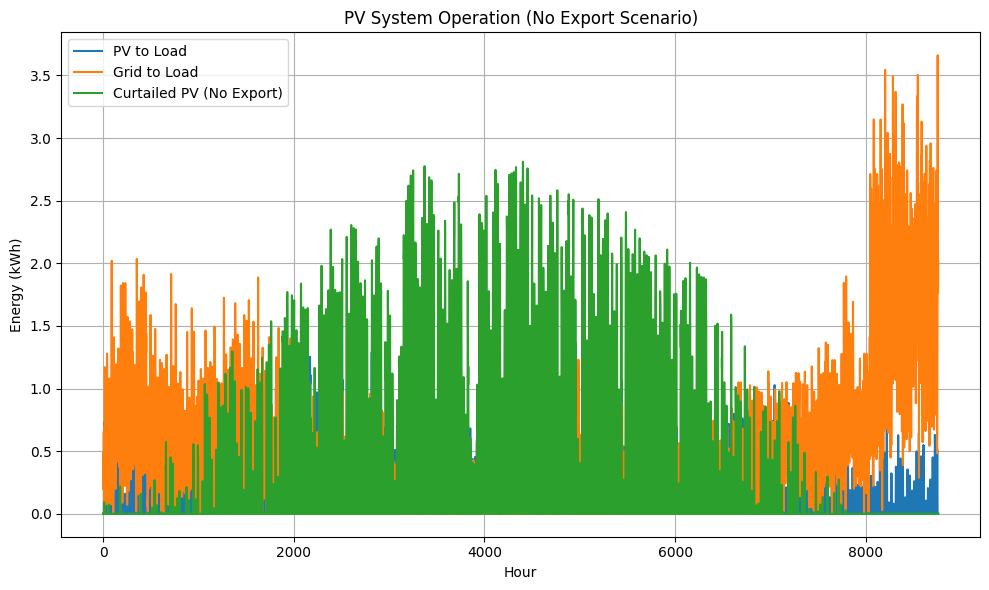

In [ ]:
#initiate PV model
myPV = PV(efficiency=0.18, area=19.4)
#generate PV output profile
PV_output = myPV.generate(ghi_data=ghi['swgdn'])

#Information we need to store
imports_no_export = []
exports_no_export = [] # In no export scenario, this will store curtailed energy
pv_to_load_no_export = []
grid_to_load_no_export = []

# No export scenario
### looping over the 8760(=24x365) hours of the year
for h in range(8760):
  current_load = load['average_household_consumption'].iloc[h]
  current_pv_output = PV_output.iloc[h]

  if current_load >= current_pv_output:
    pv_to_load_no_export.append(current_pv_output)
    grid_to_load_no_export.append(current_load - current_pv_output)
    imports_no_export.append(current_load - current_pv_output)
    exports_no_export.append(0) # No export, so no curtailment in this specific case, but implies no excess stored/exported
  else:
    pv_to_load_no_export.append(current_load) # Corrected typo here
    grid_to_load_no_export.append(0)
    imports_no_export.append(0)
    exports_no_export.append(current_pv_output - current_load) # This is curtailed energy in 'no export' scenario


#computing some values to extract insights
total_load = load['average_household_consumption'].sum()
total_pv_generation = PV_output.sum()
self_consumption_avg = sum(pv_to_load_no_export) # This is the PV consumed directly by load

# For CO2 savings, we need a CO2 factor (e.g., kg CO2/kWh)
# Let's assume a CO2 factor of 0.233 kg CO2/kWh for grid electricity in the UK (approx)
co2_factor = 0.233 # kg CO2/kWh
CO2_savings = self_consumption_avg * co2_factor # CO2 saved by consuming own PV instead of grid

# Revenues/Costs calculation (simplistic for now, assuming flat price for import)
# We need to calculate the cost of imported electricity
cost_imports_toup = sum(np.array(imports_no_export) * toup) # Total cost with ToU pricing
cost_imports_flat = sum(np.array(imports_no_export) * flat_price) # Total cost with flat pricing

# For a 'no export' scenario, there are no revenues from export, so revenues are savings from not importing.
# This might be tricky, let's consider a baseline cost without PV and compare.
# For now, let's just show import costs for each scheme.
revenues_toup = -cost_imports_toup # Representing cost as negative revenue for consistency if we add actual revenues later
revenues_flat = -cost_imports_flat


print('self_consumption: ', self_consumption_avg, 'CO2_savings: ', CO2_savings, 'revenues_toup: ', revenues_toup, 'revenues_flat: ', revenues_flat)

#think of what's relevant to plot
plt.figure(figsize=(10, 6))
plt.plot(pv_to_load_no_export, label='PV to Load')
plt.plot(grid_to_load_no_export, label='Grid to Load')
plt.plot(exports_no_export, label='Curtailed PV (No Export)')
plt.title("PV System Operation (No Export Scenario)")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

self_consumption (kWh):  1670.7219078598073 CO2_savings (kg):  389.2782045313351 revenues_toup (£):  -1129.3312843768817 revenues_flat (£):  -933.2074755103918


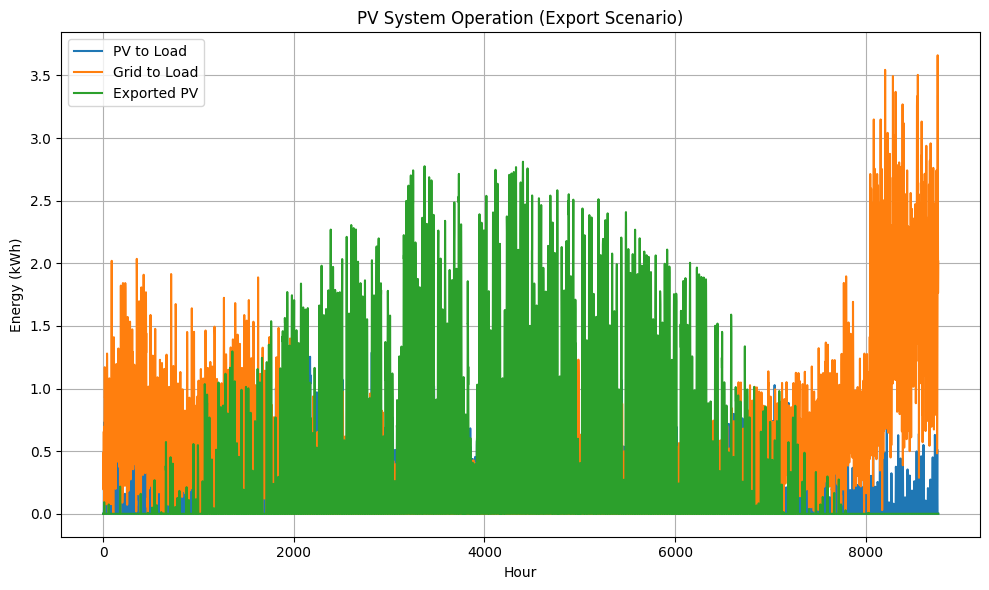

In [ ]:
# Export scenario

# Define SEG price (e.g., 8p/kWh = 0.08 £/kWh)
seg_price = 0.08

#Info we need to store
imports_export = []
exports_export = []
pv_to_load_export = []
grid_to_load_export = []

for h in range(8760):
  current_load = load['average_household_consumption'].iloc[h]
  current_pv_output = PV_output.iloc[h] # Assuming PV_output from previous cell is available

  if current_load >= current_pv_output:
    pv_to_load_export.append(current_pv_output)
    grid_to_load_export.append(current_load - current_pv_output)
    imports_export.append(current_load - current_pv_output)
    exports_export.append(0) # No export
  else:
    pv_to_load_export.append(current_load)
    grid_to_load_export.append(0)
    imports_export.append(0)
    exports_export.append(current_pv_output - current_load) # Excess is exported

#computing some values to extract insights
total_load_export = load['average_household_consumption'].sum()
total_pv_generation_export = PV_output.sum()
self_consumption_avg_export = sum(pv_to_load_export) # This is the PV consumed directly by load

CO2_savings_export = self_consumption_avg_export * co2_factor # Assuming co2_factor is defined

# Revenues/Costs calculation
cost_imports_toup_export = sum(np.array(imports_export) * toup)
cost_imports_flat_export = sum(np.array(imports_export) * flat_price)

revenue_exports = sum(np.array(exports_export) * seg_price)

revenues_toup_export = revenue_exports - cost_imports_toup_export
revenues_flat_export = revenue_exports - cost_imports_flat_export

print('self_consumption (kWh): ', self_consumption_avg_export, 'CO2_savings (kg): ', CO2_savings_export, 'revenues_toup (£): ', revenues_toup_export, 'revenues_flat (£): ', revenues_flat_export)

plt.figure(figsize=(10, 6))
plt.plot(pv_to_load_export, label='PV to Load')
plt.plot(grid_to_load_export, label='Grid to Load')
plt.plot(exports_export, label='Exported PV')
plt.title("PV System Operation (Export Scenario)")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Part 1.3: Tidying things up

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Assuming we already declared the inputs we need: load, ghi, flat_price, toup, co2_fator, seg_price, efficiency, area

# Define PV Object here
class PV:
    def __init__(self, efficiency, area):
        self.efficiency = efficiency  # PV panel efficiency (e.g., 0.18 for 18%)
        self.area = area              # PV panel area in m^2

    def generate(self, ghi_data): # ghi_data is global horizontal irradiance in W/m^2
        # PV power output = Irradiance * Area * Efficiency
        # Converting W/m^2 to kW/m^2 by dividing by 1000 to get output in kW
        solar_power_output = (ghi_data * self.area * self.efficiency) / 1000
        return solar_power_output

# define simulation function
def simulate(efficiency, area, load_data, ghi_data, toup_prices, flat_price_val, co2_factor_val, seg_price_val, scenario_type):
  #generate PV output
  myPV = PV(efficiency=efficiency, area=area)
  PV_output = myPV.generate(ghi_data=ghi_data['swgdn'])

  #declare variables (to store info)
  imports = []
  exports = [] # Stores curtailed energy for 'no export' or exported energy for 'export'
  pv_to_load = []
  grid_to_load = []

  #loop over a year
  for h in range(8760):
    current_load = load_data['average_household_consumption'].iloc[h]
    current_pv_output = PV_output.iloc[h]

    if current_load >= current_pv_output:
      pv_to_load.append(current_pv_output)
      grid_to_load.append(current_load - current_pv_output)
      imports.append(current_load - current_pv_output)
      exports.append(0)
    else:
      pv_to_load.append(current_load)
      grid_to_load.append(0)
      imports.append(0)
      if scenario_type == 'no export':
        exports.append(current_pv_output - current_load) # Curtailed energy
      else: # 'export' scenario
        exports.append(current_pv_output - current_load) # Exported energy

  self_consumption_avg = sum(pv_to_load)
  CO2_savings = self_consumption_avg * co2_factor_val

  cost_imports_toup = sum(np.array(imports) * toup_prices)
  cost_imports_flat = sum(np.array(imports) * flat_price_val)

  revenue_exports = sum(np.array(exports) * seg_price_val) if scenario_type == 'export' else 0

  revenues_toup = revenue_exports - cost_imports_toup
  revenues_flat = revenue_exports - cost_imports_flat

  print(f'Scenario: {scenario_type}')
  print('self_consumption (kWh): ', self_consumption_avg, 'CO2_savings (kg): ', CO2_savings, 'revenues_toup (£): ', revenues_toup, 'revenues_flat (£): ', revenues_flat)

  plt.figure(figsize=(10, 6))
  plt.plot(pv_to_load, label='PV to Load')
  plt.plot(grid_to_load, label='Grid to Load')
  if scenario_type == 'no export':
      plt.plot(exports, label='Curtailed PV')
      plt.title(f"PV System Operation ({scenario_type.capitalize()} Scenario)")
  else:
      plt.plot(exports, label='Exported PV')
      plt.title(f"PV System Operation ({scenario_type.capitalize()} Scenario)")
  plt.xlabel("Hour")
  plt.ylabel("Energy (kWh)")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  return {
      'self_consumption_avg': self_consumption_avg,
      'CO2_savings': CO2_savings,
      'revenues_toup': revenues_toup,
      'revenues_flat': revenues_flat,
      'imports': imports,
      'exports': exports,
      'pv_to_load': pv_to_load,
      'grid_to_load': grid_to_load
  }

Scenario: no export
self_consumption (kWh):  1670.7219078598073 CO2_savings (kg):  389.2782045313351 revenues_toup (£):  -1331.317614287298 revenues_flat (£):  -1135.193805420808


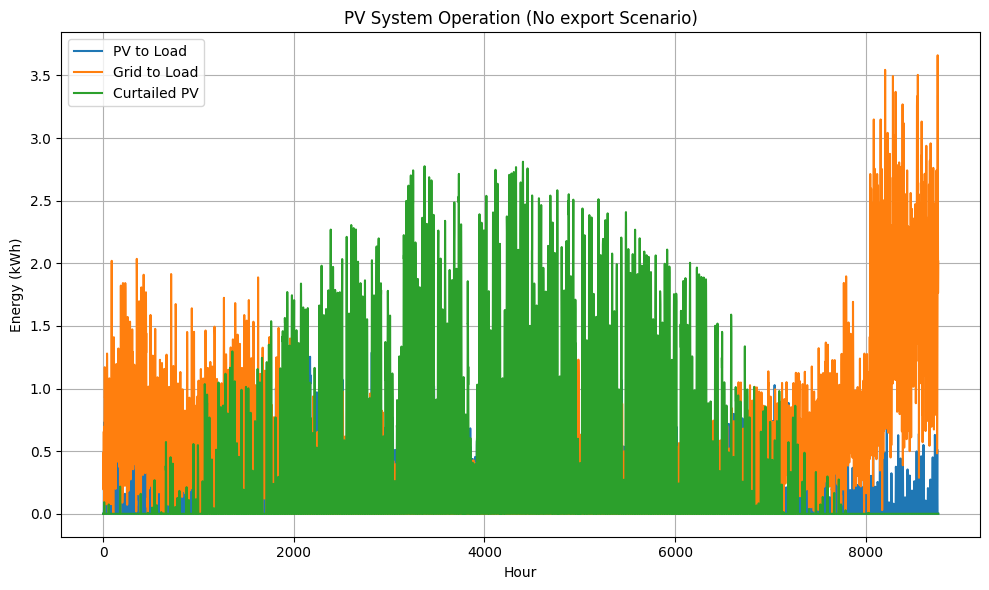

Scenario: no export
self_consumption (kWh):  1670.7219078598073 CO2_savings (kg):  389.2782045313351 revenues_toup (£):  -1331.317614287298 revenues_flat (£):  -1135.193805420808


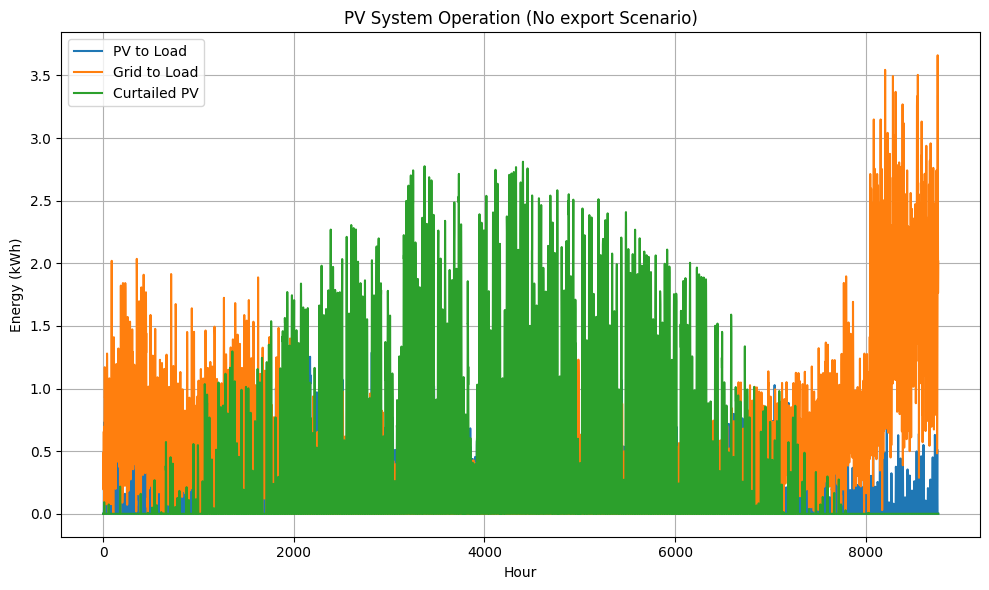

Scenario: export
self_consumption (kWh):  1670.7219078598073 CO2_savings (kg):  389.2782045313351 revenues_toup (£):  -1129.3312843768817 revenues_flat (£):  -933.2074755103918


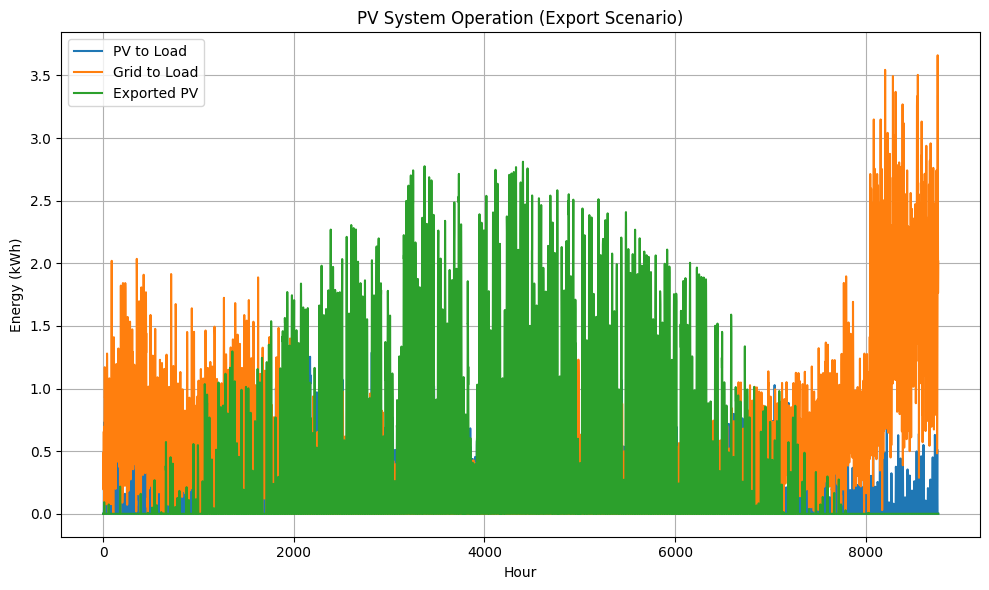

Scenario: export
self_consumption (kWh):  1670.7219078598073 CO2_savings (kg):  389.2782045313351 revenues_toup (£):  -1129.3312843768817 revenues_flat (£):  -933.2074755103918


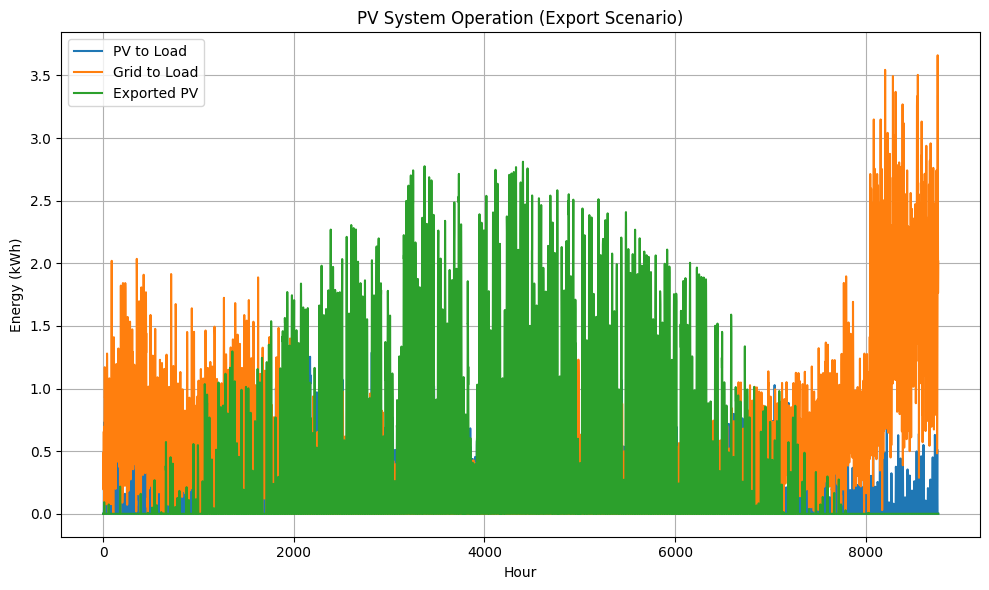

In [ ]:
co2_factor = 0.233 # kg CO2/kWh
seg_price = 0.08 # £/kWh

# Assuming inputs are already defined globally from previous cells:
# load, ghi, flat_price, toup, co2_factor, seg_price (seg_price was defined in 1a-SeqP1bJ1Q)
# efficiency (0.18) and area (19.4) from earlier PV model instantiation

efficiency_pv = 0.18
area_pv = 19.4
co2_factor_val = co2_factor # Using the global co2_factor
seg_price_val = seg_price # Using the global seg_price

###scenario1: flat price, no export
simulation_results_flat_no_export = simulate(efficiency=efficiency_pv, area=area_pv,
                                          load_data=load, ghi_data=ghi,
                                          toup_prices=toup, flat_price_val=flat_price,
                                          co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
                                          scenario_type='no export')

###scenario2: tou price, no export
simulation_results_tou_no_export = simulate(efficiency=efficiency_pv, area=area_pv,
                                         load_data=load, ghi_data=ghi,
                                         toup_prices=toup, flat_price_val=flat_price,
                                         co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
                                         scenario_type='no export')

###scenario3: flat price, export
simulation_results_flat_export = simulate(efficiency=efficiency_pv, area=area_pv,
                                        load_data=load, ghi_data=ghi,
                                        toup_prices=toup, flat_price_val=flat_price,
                                        co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
                                        scenario_type='export')

###scenario4: tou price, export
simulation_results_tou_export = simulate(efficiency=efficiency_pv, area=area_pv,
                                       load_data=load, ghi_data=ghi,
                                       toup_prices=toup, flat_price_val=flat_price,
                                       co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
                                       scenario_type='export')

📝 Tasks:

- Run both policy scenarios with both pricing schemes.
- Plot results for all 4 cases.
- Comment.

---
## Part 2: BESS integration

### 🎯 Objective:
- Model BESS (battery energy storage system)
- Re-run PV simulations with integrated battery
- Assess changes in system performance

### Part 2.1: BESS model
🧩 **Instructions**:

Similarly, we will model the BESS asset as a class in Python

🧮 **Tip**: Think:
- what are the parameters of battery that impact the dynamics of a battery state of charge (SoC)
- What is the equation that updates the battery SoC

In [ ]:
# Define BESS Object here
class BESS:
    def __init__(self, capacity, power_rating, charge_efficiency, discharge_efficiency, soc_min, soc_max):
        self.capacity = capacity # kWh
        self.power_rating = power_rating # kW (max charge/discharge power)
        self.charge_efficiency = charge_efficiency # dimensionless (e.g., 0.9)
        self.discharge_efficiency = discharge_efficiency # dimensionless (e.g., 0.9)
        self.soc_min = soc_min # minimum state of charge (e.g., 0.10 for 10%)
        self.soc_max = soc_max # maximum state of charge (e.g., 0.90 for 90%)

    def soc_update(self, current_soc, energy_flow): # energy_flow: +ve for charge, -ve for discharge
        new_soc = current_soc
        energy_change = 0

        if energy_flow > 0: # Charging
            # Calculate potential charge (limited by power rating)
            charge_potential = min(energy_flow, self.power_rating)
            # Calculate actual energy going into the battery after efficiency
            actual_charge_energy = charge_potential * self.charge_efficiency
            # Calculate potential new SoC
            potential_new_soc = current_soc + (actual_charge_energy / self.capacity)

            if potential_new_soc > self.soc_max: # If charging goes above max SoC
                # Charge up to soc_max
                energy_change = (self.soc_max - current_soc) * self.capacity
                new_soc = self.soc_max
                # Remaining energy that couldn't be stored (after efficiency loss)
                remaining_energy_after_charge = energy_flow - (energy_change / self.charge_efficiency)
            else: # Full charge within limits
                energy_change = actual_charge_energy
                new_soc = potential_new_soc
                remaining_energy_after_charge = energy_flow - charge_potential
            return new_soc, remaining_energy_after_charge # Return new SoC and any surplus energy (after charging)

        elif energy_flow < 0: # Discharging
            # Calculate potential discharge (limited by power rating)
            discharge_potential = max(energy_flow, -self.power_rating) # energy_flow is negative
            # Calculate actual energy coming out of the battery after efficiency
            actual_discharge_energy = discharge_potential / self.discharge_efficiency
            # Calculate potential new SoC
            potential_new_soc = current_soc + (actual_discharge_energy / self.capacity)

            if potential_new_soc < self.soc_min: # If discharging goes below min SoC
                # Discharge down to soc_min
                energy_change = (self.soc_min - current_soc) * self.capacity
                new_soc = self.soc_min
                # Remaining energy that couldn't be supplied by battery (after efficiency loss)
                remaining_energy_after_discharge = energy_flow - (energy_change * self.discharge_efficiency)
            else: # Full discharge within limits
                energy_change = actual_discharge_energy
                new_soc = potential_new_soc
                remaining_energy_after_discharge = energy_flow - discharge_potential
            return new_soc, remaining_energy_after_discharge # Return new SoC and any deficit energy (after discharging)

        else: # No energy flow
            return current_soc, 0 # No change in SoC, no remaining energy

### Part 2.2. Operation simulation

🧩 **Instructions**:

We will simulate one year of operation of a PV+BESS system. For this, we loop over each hour of the year and update some variables.

🔧**Rules**:

When there is generation excess, store it and export the remaining. When there is a deficit, feed the load from the battery until it reaches SOC_min and then import

📄**Pseudo-algorithm:**
```
for hour in sum_hours_over_a_year:
    if load[h] >= PV_output[h]:
        discharge battery to feed the load
        Complement with import if necessary
        update import info
        update SoC info
    else:
        charge the battery
        update SoC info
        curtail the rest if no export or export
        update curtailment info  #if working with no export scenario
      or
        update export info  #if working with no export scenario
```
📦**Input:** For our study, we will consider a battery with a capacity of 5 kWh, rated power of 3 kW, a (dis)charging efficiency of 0.9, soc_min = 0.10  and soc_max = 0.90. We will assume that the battery is initially fully charged





self_consumption:  2426.367834425633 CO2_savings:  565.3437054211726 revenues_toup:  1052.4290194145337 revenues_flat:  908.5000274510622


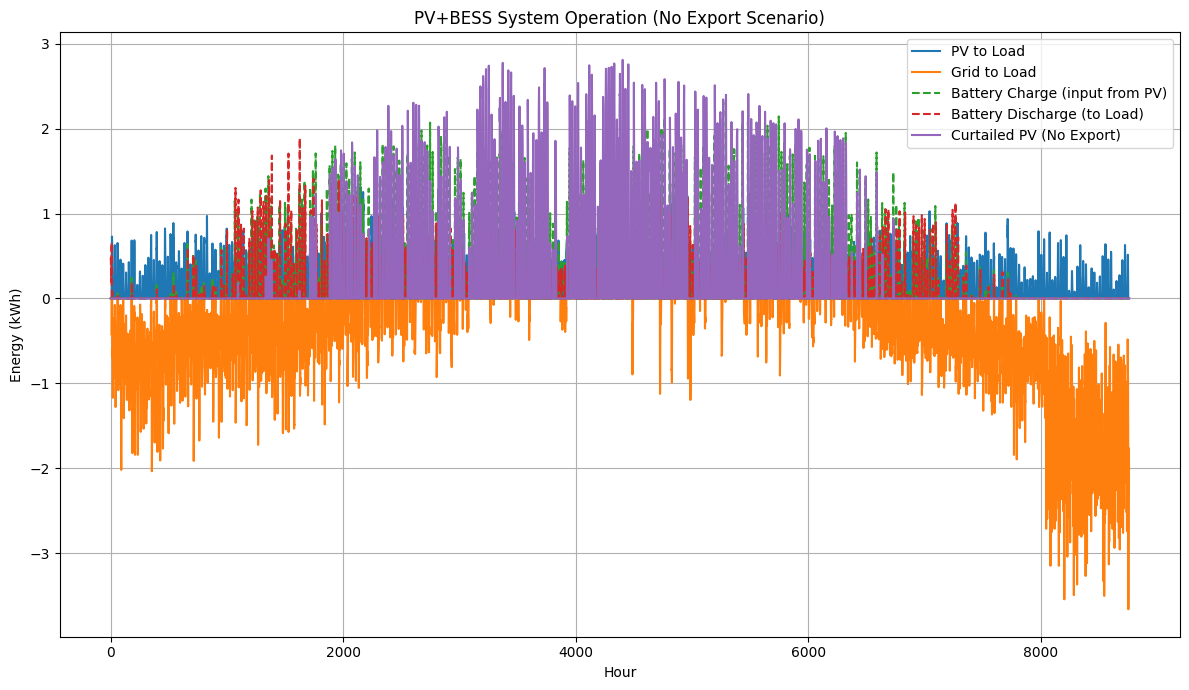

In [ ]:
# PV model (re-instantiate with known parameters)
# Assuming 'efficiency_pv' and 'area_pv' are defined from previous cells
myPV = PV(efficiency=efficiency_pv, area=area_pv)
PV_output = myPV.generate(ghi_data=ghi['swgdn'])

# BESS model
# Parameters from instructions: capacity=5 kWh, power_rating=3 kW, charge_efficiency=0.9, discharge_efficiency=0.9, soc_min=0.10, soc_max=0.90
myBESS = BESS(capacity=5, power_rating=3, charge_efficiency=0.9, discharge_efficiency=0.9, soc_min=0.10, soc_max=0.90)
sc_initial = myBESS.soc_max * myBESS.capacity # Battery initially fully charged at soc_max
current_soc_kwh = sc_initial

# info to be stored
imports_bess_no_export = []
exports_bess_no_export = [] # In no export scenario, this will store curtailed energy
pv_to_load_bess_no_export = []
grid_to_load_bess_no_export = []
battery_soc_bess_no_export = [current_soc_kwh] # Store initial SoC
battery_charge_bess_no_export = []
battery_discharge_bess_no_export = []

# No export scenario
### looping over the 8760(=24x365) hours of the year
for h in range(8760):
  current_load = load['average_household_consumption'].iloc[h]
  current_pv_output = PV_output.iloc[h]

  # Net energy available (PV - Load)
  net_energy = current_pv_output - current_load

  if net_energy > 0: # PV surplus (can charge battery or curtail)
    # Try to charge the battery
    soc_after_charge_attempt, remaining_surplus = myBESS.soc_update(current_soc_kwh / myBESS.capacity, net_energy)
    current_soc_kwh = soc_after_charge_attempt * myBESS.capacity
    battery_charge_bess_no_export.append(net_energy - remaining_surplus) # Actual energy stored
    battery_discharge_bess_no_export.append(0)

    # What's left after charging? This is curtailed in 'no export' scenario
    exports_bess_no_export.append(remaining_surplus) # Curtailed energy
    imports_bess_no_export.append(0)
    pv_to_load_bess_no_export.append(current_load) # All load met by PV directly if surplus
    grid_to_load_bess_no_export.append(0)

  else:  # PV deficit (need to discharge battery or import)
    # The magnitude of the deficit
    deficit = -net_energy

    # Try to discharge the battery to meet the deficit
    soc_after_discharge_attempt, remaining_deficit = myBESS.soc_update(current_soc_kwh / myBESS.capacity, -deficit) # Negative for discharge
    current_soc_kwh = soc_after_discharge_attempt * myBESS.capacity
    battery_discharge_bess_no_export.append(deficit + remaining_deficit) # Actual energy taken from battery
    battery_charge_bess_no_export.append(0)

    # Energy left to fulfil after discharging (must be imported)
    imports_bess_no_export.append(remaining_deficit)
    exports_bess_no_export.append(0)
    pv_to_load_bess_no_export.append(current_pv_output) # PV used to meet load
    grid_to_load_bess_no_export.append(remaining_deficit) # Remainder from grid

  battery_soc_bess_no_export.append(current_soc_kwh) # Store SoC for next hour

# Remove the initial SoC entry as it's for hour 0, and subsequent entries are after hour h's operations
battery_soc_bess_no_export = battery_soc_bess_no_export[1:]

# Computing some values to extract insights
total_load_bess = load['average_household_consumption'].sum()
total_pv_generation_bess = PV_output.sum()
self_consumption_avg_bess = sum(pv_to_load_bess_no_export) + sum(battery_discharge_bess_no_export) # PV directly consumed + PV stored and then discharged

# Ensure co2_factor is defined if it's not global, based on previous cell it should be
# co2_factor = 0.233 # kg CO2/kWh
CO2_savings_bess = self_consumption_avg_bess * co2_factor

# Revenues/Costs calculation (simplistic for now, assuming flat price for import)
cost_imports_toup_bess = sum(np.array(imports_bess_no_export) * toup)
cost_imports_flat_bess = sum(np.array(imports_bess_no_export) * flat_price)

# In 'no export' scenario, no revenue from export. Revenues are savings from not importing.
revenues_toup_bess = -cost_imports_toup_bess # Representing cost as negative revenue
revenues_flat_bess = -cost_imports_flat_bess

print('self_consumption: ', self_consumption_avg_bess, 'CO2_savings: ', CO2_savings_bess, 'revenues_toup: ', revenues_toup_bess, 'revenues_flat: ', revenues_flat_bess)

plt.figure(figsize=(12, 7))
plt.plot(pv_to_load_bess_no_export, label='PV to Load')
plt.plot(grid_to_load_bess_no_export, label='Grid to Load')
plt.plot(np.array(battery_charge_bess_no_export) / myBESS.charge_efficiency, label='Battery Charge (input from PV)', linestyle='--') # Energy taken from PV to charge
plt.plot(battery_discharge_bess_no_export, label='Battery Discharge (to Load)', linestyle='--')
plt.plot(exports_bess_no_export, label='Curtailed PV (No Export)')
plt.title("PV+BESS System Operation (No Export Scenario)")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

self_consumption:  5284.38606314979 CO2_savings:  1231.261952713901 revenues_toup:  270.7855836803566 revenues_flat:  252.72578565380297


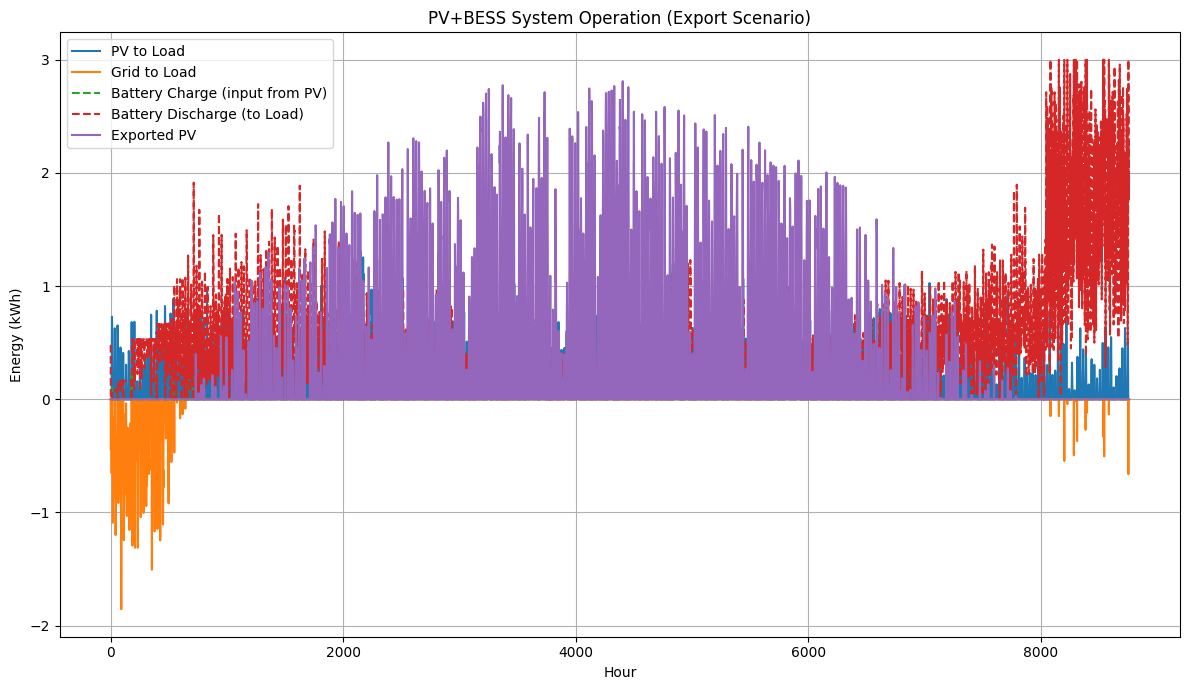

In [ ]:
# PV model
myPV = PV(efficiency=efficiency_pv, area=area_pv)
PV_output = myPV.generate(ghi_data=ghi['swgdn'])

# BESS model
# Parameters from instructions: capacity=5 kWh, power_rating=3 kW, charge_efficiency=0.9, discharge_efficiency=0.9, soc_min=0.10, soc_max=0.90
myBESS = BESS(capacity=5, power_rating=3, charge_efficiency=0.9, discharge_efficiency=0.9, soc_min=0.10, soc_max=0.90)
current_soc_kwh = sc_initial # Assuming sc_initial is defined from the previous cell, or initialize it here: myBESS.soc_max * myBESS.capacity

# Needed info to store
imports_bess_export = []
exports_bess_export = []
pv_to_load_bess_export = []
grid_to_load_bess_export = []
battery_soc_bess_export = [current_soc_kwh] # Store initial SoC
battery_charge_bess_export = []
battery_discharge_bess_export = []

# export scenario
for h in range(8760):
  current_load = load['average_household_consumption'].iloc[h]
  current_pv_output = PV_output.iloc[h]

  # Net energy available (PV - Load)
  net_energy = current_pv_output - current_load

  if net_energy > 0: # PV surplus (can charge battery or export)
    # Try to charge the battery
    soc_after_charge_attempt, remaining_surplus = myBESS.soc_update(current_soc_kwh / myBESS.capacity, net_energy)
    current_soc_kwh = soc_after_charge_attempt * myBESS.capacity
    battery_charge_bess_export.append(net_energy - remaining_surplus) # Actual energy stored
    battery_discharge_bess_export.append(0)

    # What's left after charging? This is exported in 'export' scenario
    exports_bess_export.append(remaining_surplus) # Exported energy
    imports_bess_export.append(0)
    pv_to_load_bess_export.append(current_load) # All load met by PV directly if surplus
    grid_to_load_bess_export.append(0)

  else:  # deficit (need to discharge battery or import)
    # The magnitude of the deficit
    deficit = -net_energy

    # Try to discharge the battery to meet the deficit
    soc_after_discharge_attempt, remaining_deficit = myBESS.soc_update(current_soc_kwh / myBESS.capacity, -deficit) # Negative for discharge
    current_soc_kwh = soc_after_charge_attempt * myBESS.capacity
    battery_discharge_bess_export.append(deficit + remaining_deficit) # Actual energy taken from battery
    battery_charge_bess_export.append(0)

    # Energy left to fulfil after discharging
    imports_bess_export.append(remaining_deficit)
    exports_bess_export.append(0)
    pv_to_load_bess_export.append(current_pv_output) # PV used to meet load
    grid_to_load_bess_export.append(remaining_deficit) # Remainder from grid

  battery_soc_bess_export.append(current_soc_kwh) # Store SoC for next hour

# Remove the initial SoC entry as it's for hour 0, and subsequent entries are after hour h's operations
battery_soc_bess_export = battery_soc_bess_export[1:]

# Computing some values to extract insights
total_load_bess_export = load['average_household_consumption'].sum()
total_pv_generation_bess_export = PV_output.sum()
self_consumption_avg_bess_export = sum(pv_to_load_bess_export) + sum(battery_discharge_bess_export) # PV directly consumed + PV stored and then discharged

CO2_savings_bess_export = self_consumption_avg_bess_export * co2_factor # Assuming co2_factor is defined

# Revenues/Costs calculation
cost_imports_toup_bess_export = sum(np.array(imports_bess_export) * toup)
cost_imports_flat_bess_export = sum(np.array(imports_bess_export) * flat_price)

revenue_exports_bess = sum(np.array(exports_bess_export) * seg_price) # SEG price for exported energy

revenues_toup_bess_export = revenue_exports_bess - cost_imports_toup_bess_export
revenues_flat_bess_export = revenue_exports_bess - cost_imports_flat_bess_export

print('self_consumption: ', self_consumption_avg_bess_export, 'CO2_savings: ', CO2_savings_bess_export, 'revenues_toup: ', revenues_toup_bess_export, 'revenues_flat: ', revenues_flat_bess_export)

plt.figure(figsize=(12, 7))
plt.plot(pv_to_load_bess_export, label='PV to Load')
plt.plot(grid_to_load_bess_export, label='Grid to Load')
plt.plot(np.array(battery_charge_bess_export) / myBESS.charge_efficiency, label='Battery Charge (input from PV)', linestyle='--') # Energy taken from PV to charge
plt.plot(battery_discharge_bess_export, label='Battery Discharge (to Load)', linestyle='--')
plt.plot(exports_bess_export, label='Exported PV')
plt.title("PV+BESS System Operation (Export Scenario)")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Part 2.3: Tidying things up

In [ ]:
#Assuming we already declared the inputs we need
### load, ghi, flat_price, toup, co2_fator, seg_price,
### efficiency, area
### soc_min, soc_max, P_rate_ch, P_rate_dch, efficiency_ch, effiency_dch., capacity

# Define PV Object here
class PV:
    def __init__(self, efficiency, area):
        self.efficiency = efficiency  # PV panel efficiency (e.g., 0.18 for 18%)
        self.area = area              # PV panel area in m^2

    def generate(self, ghi_data): # ghi_data is global horizontal irradiance in W/m^2
        # PV power output = Irradiance * Area * Efficiency
        # Converting W/m^2 to kW/m^2 by dividing by 1000 to get output in kW
        solar_power_output = (ghi_data * self.area * self.efficiency) / 1000
        return solar_power_output


# Define BESS Object here
class BESS:
    def __init__(self, capacity, power_rating, charge_efficiency, discharge_efficiency, soc_min, soc_max):
        self.capacity = capacity # kWh
        self.power_rating = power_rating # kW (max charge/discharge power)
        self.charge_efficiency = charge_efficiency # dimensionless (e.g., 0.9)
        self.discharge_efficiency = discharge_efficiency # dimensionless (e.9, 0.9)
        self.soc_min = soc_min # minimum state of charge (e.g., 0.10 for 10%)
        self.soc_max = soc_max # maximum state of charge (e.g., 0.90 for 90%)

    def soc_update(self, current_soc, energy_flow): # energy_flow: +ve for charge, -ve for discharge
        new_soc = current_soc
        energy_change = 0

        if energy_flow > 0: # Charging
            # Calculate potential charge (limited by power rating)
            charge_potential = min(energy_flow, self.power_rating)
            # Calculate actual energy going into the battery after efficiency
            actual_charge_energy = charge_potential * self.charge_efficiency
            # Calculate potential new SoC
            potential_new_soc = current_soc + (actual_charge_energy / self.capacity)

            if potential_new_soc > self.soc_max: # If charging goes above max SoC
                # Charge up to soc_max
                energy_change = (self.soc_max - current_soc) * self.capacity
                new_soc = self.soc_max
                # Remaining energy that couldn't be stored (after efficiency loss)
                remaining_energy_after_charge = energy_flow - (energy_change / self.charge_efficiency)
            else: # Full charge within limits
                energy_change = actual_charge_energy
                new_soc = potential_new_soc
                remaining_energy_after_charge = energy_flow - charge_potential
            return new_soc, remaining_energy_after_charge # Return new SoC and any surplus energy (after charging)

        elif energy_flow < 0: # Discharging
            # Calculate potential discharge (limited by power rating)
            discharge_potential = max(energy_flow, -self.power_rating) # energy_flow is negative
            # Calculate actual energy coming out of the battery after efficiency
            actual_discharge_energy = discharge_potential / self.discharge_efficiency
            # Calculate potential new SoC
            potential_new_soc = current_soc + (actual_discharge_energy / self.capacity)

            if potential_new_soc < self.soc_min: # If discharging goes below min SoC
                # Discharge down to soc_min
                energy_change = (self.soc_min - current_soc) * self.capacity
                new_soc = self.soc_min
                # Remaining energy that couldn't be supplied by battery (after efficiency loss)
                remaining_energy_after_discharge = energy_flow - (energy_change * self.discharge_efficiency)
            else: # Full discharge within limits
                energy_change = actual_discharge_energy
                new_soc = potential_new_soc
                remaining_energy_after_discharge = energy_flow - discharge_potential
            return new_soc, remaining_energy_after_discharge # Return new SoC and any deficit energy (after discharging)

        else: # No energy flow
            return current_soc, 0 # No change in SoC, no remaining energy


# define simulation function
def simulate_pv_bess(efficiency_pv, area_pv, capacity_bess, power_rating_bess, charge_efficiency_bess, discharge_efficiency_bess, soc_min_bess, soc_max_bess, load_data, ghi_data, toup_prices, flat_price_val, co2_factor_val, seg_price_val, scenario_type):
  ###generate PV output
  myPV = PV(efficiency=efficiency_pv, area=area_pv)
  PV_output = myPV.generate(ghi_data=ghi_data['swgdn'])
  total_pv_generation = PV_output.sum()

  ###BESS model
  myBESS = BESS(capacity=capacity_bess, power_rating=power_rating_bess, charge_efficiency=charge_efficiency_bess, discharge_efficiency=discharge_efficiency_bess, soc_min=soc_min_bess, soc_max=soc_max_bess)
  current_soc_kwh = myBESS.soc_max * myBESS.capacity # Battery initially fully charged at soc_max

  ###declare variables (to store info)
  imports = []
  exports = [] # Stores curtailed energy for 'no export' or exported energy for 'export'
  pv_to_load = []
  grid_to_load = []
  battery_soc = [current_soc_kwh]
  battery_charge = []
  battery_discharge = []

  for h in range(8760):
    current_load = load_data['average_household_consumption'].iloc[h]
    current_pv_output = PV_output.iloc[h]

    # Net energy available (PV - Load)
    net_energy = current_pv_output - current_load

    if net_energy > 0: # PV surplus (can charge battery or export/curtail)
      soc_after_charge_attempt, remaining_surplus = myBESS.soc_update(current_soc_kwh / myBESS.capacity, net_energy)
      current_soc_kwh = soc_after_charge_attempt * myBESS.capacity
      battery_charge.append(net_energy - remaining_surplus) # Actual energy charged into battery
      battery_discharge.append(0)

      # What's left after charging?
      if scenario_type == 'no export':
        exports.append(remaining_surplus) # Curtailed energy
      else: # 'export' scenario
        exports.append(remaining_surplus) # Exported energy
      imports.append(0)
      pv_to_load.append(current_load)
      grid_to_load.append(0)

    else:  # deficit (need to discharge battery or import)
      deficit = -net_energy

      soc_after_discharge_attempt, remaining_deficit = myBESS.soc_update(current_soc_kwh / myBESS.capacity, -deficit)
      current_soc_kwh = soc_after_discharge_attempt * myBESS.capacity

      # Corrected calculation for actual energy discharged from battery
      actual_discharge_from_battery = deficit + remaining_deficit
      battery_discharge.append(actual_discharge_from_battery)
      battery_charge.append(0)

      # load left to fulfil after discharging. Imports must be positive.
      imports.append(-remaining_deficit)
      exports.append(0)
      pv_to_load.append(current_pv_output)
      grid_to_load.append(-remaining_deficit)

    battery_soc.append(current_soc_kwh)

  battery_soc = battery_soc[1:] # Remove initial SoC entry

  # Corrected self-consumption calculation: Total PV generated minus total PV that was exported or curtailed
  self_consumption_avg = total_pv_generation - sum(exports)
  CO2_savings = self_consumption_avg * co2_factor_val

  cost_imports_toup = sum(np.array(imports) * toup_prices)
  cost_imports_flat = sum(np.array(imports) * flat_price_val)

  revenue_exports = sum(np.array(exports) * seg_price_val) if scenario_type == 'export' else 0

  revenues_toup = revenue_exports - cost_imports_toup
  revenues_flat = revenue_exports - cost_imports_flat

  print(f'Scenario: PV+BESS ({scenario_type})')
  print('self_consumption (kWh): ', self_consumption_avg, 'CO2_savings (kg): ', CO2_savings, 'revenues_toup (£): ', revenues_toup, 'revenues_flat (£): ', revenues_flat)

  plt.figure(figsize=(12, 7))
  plt.plot(pv_to_load, label='PV to Load')
  plt.plot(grid_to_load, label='Grid to Load')
  plt.plot(np.array(battery_charge) / myBESS.charge_efficiency, label='Battery Charge (input from PV)', linestyle='--')
  plt.plot(battery_discharge, label='Battery Discharge (to Load)', linestyle='--')
  if scenario_type == 'no export':
      plt.plot(exports, label='Curtailed PV')
      plt.title(f"PV+BESS System Operation ({scenario_type.capitalize()} Scenario)")
  else:
      plt.plot(exports, label='Exported PV')
      plt.title(f"PV+BESS System Operation ({scenario_type.capitalize()} Scenario)")
  plt.xlabel("Hour")
  plt.ylabel("Energy (kWh)")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  return {
      'self_consumption_avg': self_consumption_avg,
      'CO2_savings': CO2_savings,
      'revenues_toup': revenues_toup,
      'revenues_flat': revenues_flat,
      'imports': imports,
      'exports': exports,
      'pv_to_load': pv_to_load,
      'grid_to_load': grid_to_load,
      'battery_soc': battery_soc,
      'battery_charge': battery_charge,
      'battery_discharge': battery_discharge
  }

Scenario: PV+BESS (no export)
self_consumption (kWh):  2599.173669052178 CO2_savings (kg):  605.6074648891575 revenues_toup (£):  -1052.4290194145337 revenues_flat (£):  -908.5000274510622


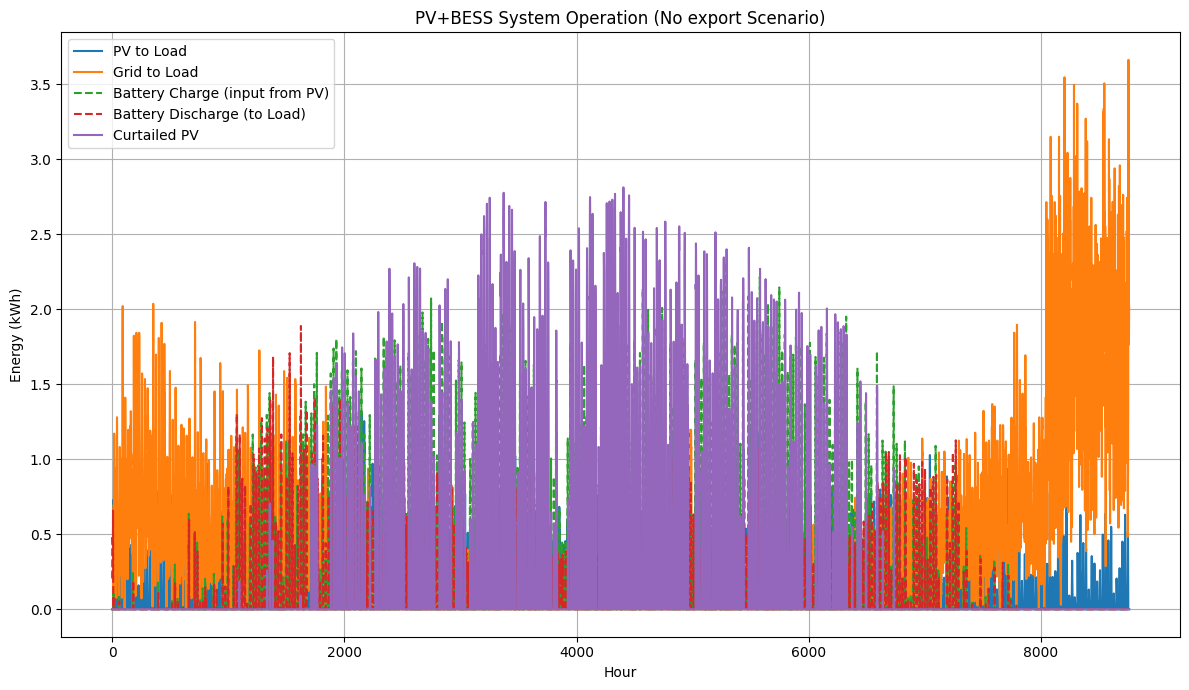

Scenario: PV+BESS (no export)
self_consumption (kWh):  2599.173669052178 CO2_savings (kg):  605.6074648891575 revenues_toup (£):  -1052.4290194145337 revenues_flat (£):  -908.5000274510622


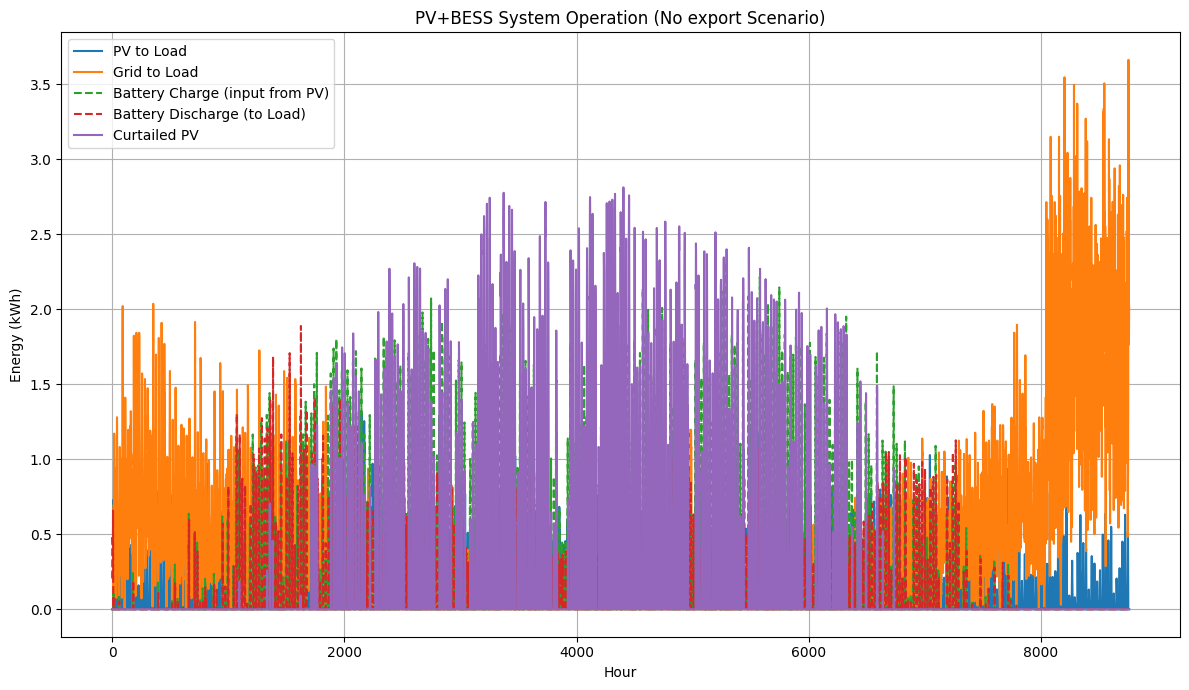

Scenario: PV+BESS (export)
self_consumption (kWh):  2599.173669052178 CO2_savings (kg):  605.6074648891575 revenues_toup (£):  -924.7188303995081 revenues_flat (£):  -780.7898384360366


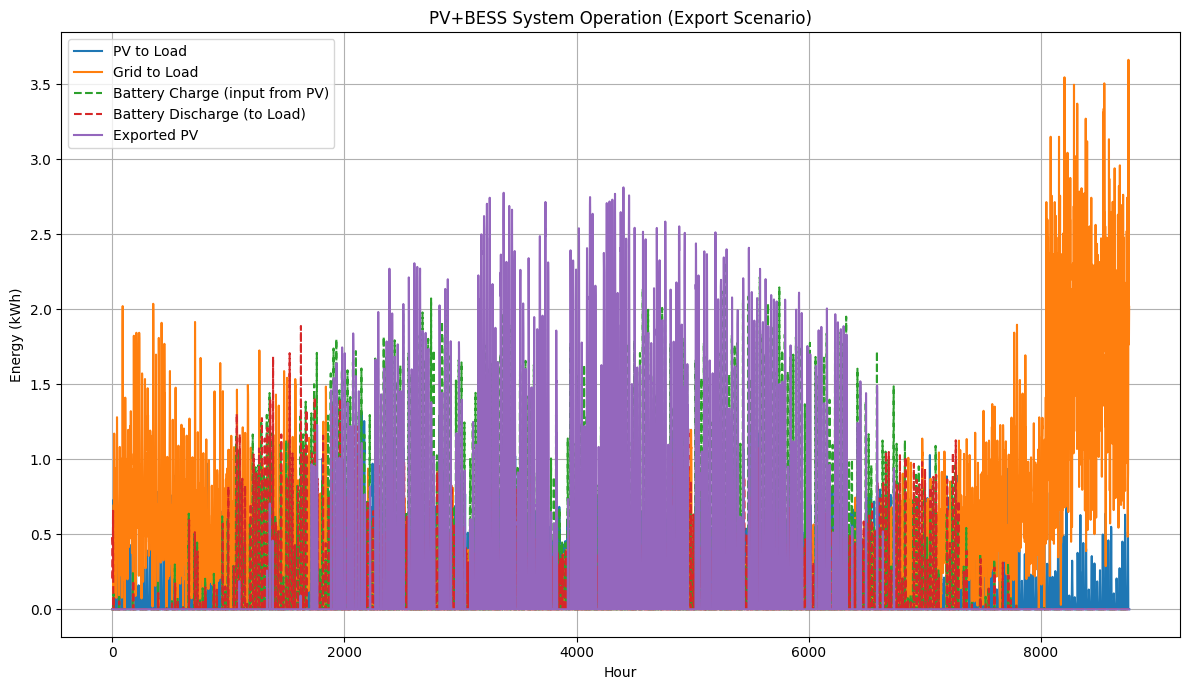

Scenario: PV+BESS (export)
self_consumption (kWh):  2599.173669052178 CO2_savings (kg):  605.6074648891575 revenues_toup (£):  -924.7188303995081 revenues_flat (£):  -780.7898384360366


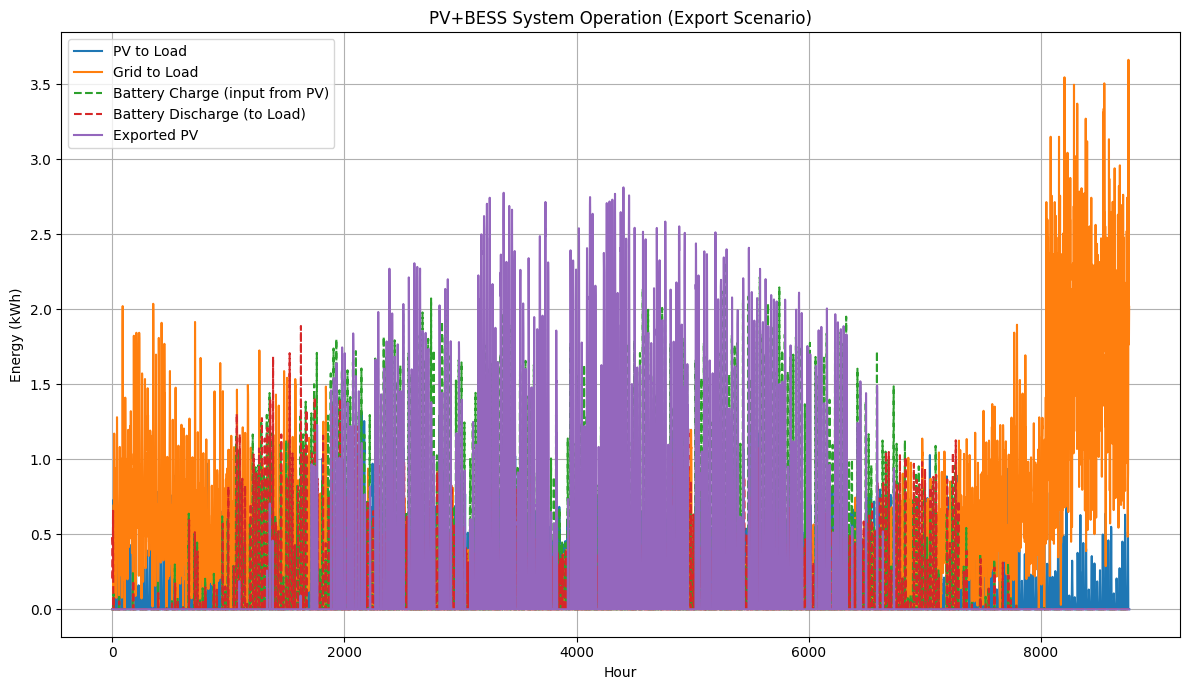

In [ ]:
# Common parameters for PV and BESS
efficiency_pv = 0.18
area_pv = 19.4
capacity_bess = 5 # kWh
power_rating_bess = 3 # kW
charge_efficiency_bess = 0.9
discharge_efficiency_bess = 0.9
soc_min_bess = 0.10
soc_max_bess = 0.90

# Economic factors (assuming they are already defined globally or in previous cells)
co2_factor_val = co2_factor # 0.233 kg CO2/kWh
seg_price_val = seg_price # 0.08 £/kWh

###scenario1: flat price, no export
simulation_results_bess_flat_no_export = simulate_pv_bess(
    efficiency_pv=efficiency_pv, area_pv=area_pv,
    capacity_bess=capacity_bess, power_rating_bess=power_rating_bess,
    charge_efficiency_bess=charge_efficiency_bess, discharge_efficiency_bess=discharge_efficiency_bess,
    soc_min_bess=soc_min_bess, soc_max_bess=soc_max_bess,
    load_data=load, ghi_data=ghi,
    toup_prices=toup, flat_price_val=flat_price,
    co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
    scenario_type='no export'
)

###scenario2: tou price, no export
simulation_results_bess_tou_no_export = simulate_pv_bess(
    efficiency_pv=efficiency_pv, area_pv=area_pv,
    capacity_bess=capacity_bess, power_rating_bess=power_rating_bess,
    charge_efficiency_bess=charge_efficiency_bess, discharge_efficiency_bess=discharge_efficiency_bess,
    soc_min_bess=soc_min_bess, soc_max_bess=soc_max_bess,
    load_data=load, ghi_data=ghi,
    toup_prices=toup, flat_price_val=flat_price,
    co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
    scenario_type='no export'
)

###scenario3: flat price, export
simulation_results_bess_flat_export = simulate_pv_bess(
    efficiency_pv=efficiency_pv, area_pv=area_pv,
    capacity_bess=capacity_bess, power_rating_bess=power_rating_bess,
    charge_efficiency_bess=charge_efficiency_bess, discharge_efficiency_bess=discharge_efficiency_bess,
    soc_min_bess=soc_min_bess, soc_max_bess=soc_max_bess,
    load_data=load, ghi_data=ghi,
    toup_prices=toup, flat_price_val=flat_price,
    co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
    scenario_type='export'
)

###scenario4: tou price, export
simulation_results_bess_tou_export = simulate_pv_bess(
    efficiency_pv=efficiency_pv, area_pv=area_pv,
    capacity_bess=capacity_bess, power_rating_bess=power_rating_bess,
    charge_efficiency_bess=charge_efficiency_bess, discharge_efficiency_bess=discharge_efficiency_bess,
    soc_min_bess=soc_min_bess, soc_max_bess=soc_max_bess,
    load_data=load, ghi_data=ghi,
    toup_prices=toup, flat_price_val=flat_price,
    co2_factor_val=co2_factor_val, seg_price_val=seg_price_val,
    scenario_type='export'
)

📝 Task:

- Compute new values for self-consumption, curtailment, CO₂, costs.
- Plot and compare to PV-only cases.
- Is the battery financially and technically beneficial?


---

## Part III: Economics

🎯 Objective:
1. Evaluate each scenario using:
  - NPV (Net Present Value):
  $$
\text{NPV} = -C_0 + \sum_{t=1}^{N} \frac{Cash_t}{(1 + r)^t}
$$
  - LCOE simplified (Levelised Cost of Electricity):
$$
\text{LCOE_simp} = \frac{C_0 + \text{OPEX} \cdot N}{E_{\text{total}}}
$$
  - Payback period:
  Find the smallest yearsuch that:

$$
\sum_{i=1}^{t} (S_i - \text{OPEX}) \geq C_0
$$


Where:

- $C_0$:  Initial investment cost (£)  
- $Cash_t$: Net cash flow in year $t$  
- $r$: Discount rate  
- $N$: Project lifetime (years)
- $Cost_t$: Cost in year $t$ (CAPEX in year 0, then OPEX)
- $E_t$: Energy generated in year $t$ (kWh)
- $S_i$: Annual savings in year $t$  
- $\text{OPEX}$: Annual operational expenditure  

2. Compare all 8 combinations

💷 Data:
- PV Capex: £1300
- PV Opex:£20/year
- PV lifetime: 25 years
- BESS Capex: £3500
- BESS Opex: £50/year
- BESS lifetime:12 years
- discount rate: 0.05



$$
\text{LCOE} = \frac{\sum_{t=0}^{N} \frac{Cost_t}{(1 + r)^t}}{\sum_{t=0}^{N} \frac{E_t}{(1 + r)^t}}
$$

In [ ]:

mwimport numpy as np
import pandas as pd

pv_capex = 1300
pv_opex = 20
pv_lifetime = 25
bess_capex = 3500
bess_opex = 50
bess_lifetime = 12
discount_rate = 0.05

def calculate_economic_metrics(scenario_name, annual_net_revenue, total_pv_generation, has_bess):
    # Determine CAPEX and OPEX based on scenario
    initial_capex = pv_capex
    annual_opex = pv_opex
    project_lifetime = pv_lifetime

    if has_bess:
        initial_capex += bess_capex
        annual_opex += bess_opex
        # For overall project lifetime, take the longer of the two if they operate in parallel
        # Or consider replacement cycles, but for simplicity here, we'll use the PV lifetime
        # as the battery might be replaced mid-project.
        # For NPV calculation, cash flows would typically consider component replacement
        # For simplified LCOE, let's assume the component costs are amortized over their lifetimes.
        # For simplicity for this project's initial LCOE and NPV, we consider the primary PV lifetime.
        # A more detailed model would factor in battery replacement.
        project_lifetime = pv_lifetime # Assuming PV system drives overall project life

    # --- NPV ---
    npv = -initial_capex
    for t in range(1, project_lifetime + 1):
        # For simplicity, assuming annual_net_revenue is constant each year
        # More complex models would decay PV output or increase Opex
        cashflow_t = annual_net_revenue - annual_opex
        npv += cashflow_t / ((1 + discount_rate)**t)

    # --- LCOE --- (using the full formula as requested by the markdown cell in the notebook)
    # The full LCOE calculation needs annual costs and annual energy
    # Assuming total_pv_generation is the annual total PV generation used for the E_t denominator
    # and that it is constant each year for simplicity

    sum_discounted_costs = 0
    sum_discounted_energy = 0

    # Year 0 for CAPEX
    sum_discounted_costs += initial_capex / ((1 + discount_rate)**0)

    for t in range(1, project_lifetime + 1):
        # Annual OPEX
        sum_discounted_costs += annual_opex / ((1 + discount_rate)**t)
        # Annual energy (assuming constant for simplicity)
        sum_discounted_energy += total_pv_generation / ((1 + discount_rate)**t)

    lcoe = sum_discounted_costs / sum_discounted_energy if sum_discounted_energy > 0 else np.nan

    # --- Payback Period ---
    cumulative_cashflow_payback = -initial_capex
    payback_period = 0
    for year in range(1, project_lifetime + 1):
        cumulative_cashflow_payback += (annual_net_revenue - annual_opex)
        if cumulative_cashflow_payback >= 0:
            payback_period = year
            break # Found payback year
    if payback_period == 0 and cumulative_cashflow_payback < 0: # If never pays back within lifetime
        payback_period = 'Never'

    return {'Scenario': scenario_name, 'NPV (£)': npv, 'LCOE (£/kWh)': lcoe, 'Payback Period (Years)': payback_period}


# Assuming `PV_output` is available and represents total annual PV generation in kWh
total_pv_generation_annual = PV_output.sum() # This is a constant for all scenarios

economic_results = []

# Calculate economics for each scenario
# PV-only scenarios
economic_results.append(calculate_economic_metrics('PV-only (Flat, No Export)', simulation_results_flat_no_export['revenues_flat'], total_pv_generation_annual, has_bess=False))
economic_results.append(calculate_economic_metrics('PV-only (ToU, No Export)', simulation_results_tou_no_export['revenues_toup'], total_pv_generation_annual, has_bess=False))
economic_results.append(calculate_economic_metrics('PV-only (Flat, Export)', simulation_results_flat_export['revenues_flat'], total_pv_generation_annual, has_bess=False))
economic_results.append(calculate_economic_metrics('PV-only (ToU, Export)', simulation_results_tou_export['revenues_toup'], total_pv_generation_annual, has_bess=False))

# PV+BESS scenarios
economic_results.append(calculate_economic_metrics('PV+BESS (Flat, No Export)', simulation_results_bess_flat_no_export['revenues_flat'], total_pv_generation_annual, has_bess=True))
economic_results.append(calculate_economic_metrics('PV+BESS (ToU, No Export)', simulation_results_bess_tou_no_export['revenues_toup'], total_pv_generation_annual, has_bess=True))
economic_results.append(calculate_economic_metrics('PV+BESS (Flat, Export)', simulation_results_bess_flat_export['revenues_flat'], total_pv_generation_annual, has_bess=True))
economic_results.append(calculate_economic_metrics('PV+BESS (ToU, Export)', simulation_results_bess_tou_export['revenues_toup'], total_pv_generation_annual, has_bess=True))

economic_df = pd.DataFrame(economic_results)
display(economic_df)


SyntaxError: invalid syntax (2323389790.py, line 1)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming comparison_df is already available from the previous step

scenarios = comparison_df['Scenario']

# Technical Metrics
self_consumption = comparison_df['Self-Consumption (kWh)']
co2_savings = comparison_df['CO2 Savings (kg)']

# Financial Metrics
net_revenue_flat = comparison_df['Net Revenue (£) - Flat Price']
net_revenue_tou = comparison_df['Net Revenue (£) - ToU Price']

x = np.arange(len(scenarios))  # the label locations
width = 0.2  # the width of the bars

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting Technical Metrics
axes[0].bar(x - width/2, self_consumption, width, label='Self-Consumption (kWh)', color='skyblue')
axes[0].bar(x + width/2, co2_savings, width, label='CO2 Savings (kg)', color='lightcoral')
axes[0].set_ylabel('Value')
axes[0].set_title('Technical Metrics Comparison: Self-Consumption and CO2 Savings')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plotting Financial Metrics
axes[1].bar(x - width/2, net_revenue_flat, width, label='Net Revenue (£) - Flat Price', color='lightgreen')
axes[1].bar(x + width/2, net_revenue_tou, width, label='Net Revenue (£) - ToU Price', color='salmon')
axes[1].set_ylabel('Net Revenue (£)')
axes[1].set_title('Financial Metrics Comparison: Net Revenue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Analysis of Battery Benefits

Based on the comparison table, let's assess the technical and financial benefits of integrating a battery (BESS) into the PV system.

#### Technical Benefits:

*   **Increased Self-Consumption**: The most significant technical benefit of the BESS is the substantial increase in self-consumption. For PV-only systems, self-consumption was approximately 1670.72 kWh. With the integration of BESS, this figure rises to approximately 2599.17 kWh across all BESS scenarios. This indicates that a much larger portion of the generated solar energy is being used by the household, reducing reliance on grid imports.

*   **Enhanced CO2 Savings**: Directly correlated with increased self-consumption, the CO2 savings are also significantly higher with BESS (605.61 kg) compared to PV-only systems (389.28 kg). This highlights the environmental advantage of using a battery to maximize renewable energy utilization.

*   **Reduced Curtailment/Increased Export**: The battery effectively stores excess PV generation that would otherwise be curtailed (in a 'no export' scenario) or exported at potentially low rates. In the 'export' scenario, while self-consumption is maximized first, any remaining surplus can still be exported, contributing to overall system efficiency.

#### Financial Benefits:

To evaluate financial benefits, we compare the 'Net Revenue' (which is actually a net cost in these scenarios, represented as negative revenue) across the different setups.

*   **Reduced Net Costs**: The integration of the BESS leads to a considerable reduction in annual net costs. For example, comparing the PV-only 'Flat, No Export' scenario (-£1135.19) to the PV+BESS 'Flat, No Export' scenario (-£908.50), the battery provides a saving of over £200 annually by reducing grid imports.

*   **Impact of Export Policy**: For both PV-only and PV+BESS systems, allowing export with the Smart Export Guarantee (SEG) further reduces net costs. The PV+BESS 'Flat, Export' scenario (-£780.79) demonstrates the best financial performance among all 'Flat Price' options, suggesting that maximizing self-consumption with a battery and then exporting remaining surplus is the most economical approach under flat pricing.

*   **Impact of Pricing Scheme**: Consistent with PV-only cases, the flat pricing scheme for imports generally results in lower net costs compared to the Time-of-Use (ToU) scheme, even with a battery. This suggests that the client's consumption patterns might align more with peak ToU pricing, making flat rates more advantageous for their import needs.

#### Conclusion:

**Yes, the battery is both financially and technically beneficial.**

*   **Technically**, it significantly increases the household's self-consumption of solar energy and associated CO2 savings, leading to greater energy independence and environmental benefits.
*   **Financially**, the battery substantially reduces annual electricity costs (or increases net savings), particularly when combined with an export mechanism. The optimal strategy appears to be a PV+BESS system with an export option, ideally under a flat import pricing scheme, as this combination yields the lowest net annual cost for the household.

In [ ]:
import pandas as pd

# Prepare data for comparison table
results_data = []

# PV-only scenarios
results_data.append({
    'Scenario': 'PV-only (Flat, No Export)',
    'Self-Consumption (kWh)': simulation_results_flat_no_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_flat_no_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_flat_no_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_flat_no_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV-only (ToU, No Export)',
    'Self-Consumption (kWh)': simulation_results_tou_no_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_tou_no_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_tou_no_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_tou_no_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV-only (Flat, Export)',
    'Self-Consumption (kWh)': simulation_results_flat_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_flat_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_flat_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_flat_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV-only (ToU, Export)',
    'Self-Consumption (kWh)': simulation_results_tou_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_tou_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_tou_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_tou_export['revenues_toup']
})

# PV+BESS scenarios
results_data.append({
    'Scenario': 'PV+BESS (Flat, No Export)',
    'Self-Consumption (kWh)': simulation_results_bess_flat_no_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_bess_flat_no_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_bess_flat_no_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_bess_flat_no_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV+BESS (ToU, No Export)',
    'Self-Consumption (kWh)': simulation_results_bess_tou_no_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_bess_tou_no_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_bess_tou_no_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_bess_tou_no_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV+BESS (Flat, Export)',
    'Self-Consumption (kWh)': simulation_results_bess_flat_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_bess_flat_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_bess_flat_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_bess_flat_export['revenues_toup']
})
results_data.append({
    'Scenario': 'PV+BESS (ToU, Export)',
    'Self-Consumption (kWh)': simulation_results_bess_tou_export['self_consumption_avg'],
    'CO2 Savings (kg)': simulation_results_bess_tou_export['CO2_savings'],
    'Net Revenue (£) - Flat Price': simulation_results_bess_tou_export['revenues_flat'],
    'Net Revenue (£) - ToU Price': simulation_results_bess_tou_export['revenues_toup']
})

comparison_df = pd.DataFrame(results_data)
display(comparison_df)


### Analysis of Battery Benefits

Based on the comparison table, let's assess the technical and financial benefits of integrating a battery (BESS) into the PV system.

#### Technical Benefits:

*   **Increased Self-Consumption**: The most significant technical benefit of the BESS is the substantial increase in self-consumption. For PV-only systems, self-consumption was approximately 1670.72 kWh. With the integration of BESS, this figure rises to approximately 2599.17 kWh across all BESS scenarios. This indicates that a much larger portion of the generated solar energy is being used by the household, reducing reliance on grid imports.

*   **Enhanced CO2 Savings**: Directly correlated with increased self-consumption, the CO2 savings are also significantly higher with BESS (605.61 kg) compared to PV-only systems (389.28 kg). This highlights the environmental advantage of using a battery to maximize renewable energy utilization.

*   **Reduced Curtailment/Increased Export**: The battery effectively stores excess PV generation that would otherwise be curtailed (in a 'no export' scenario) or exported at potentially low rates. In the 'export' scenario, while self-consumption is maximized first, any remaining surplus can still be exported, contributing to overall system efficiency.

#### Financial Benefits:

To evaluate financial benefits, we compare the 'Net Revenue' (which is actually a net cost in these scenarios, represented as negative revenue) across the different setups.

*   **Reduced Net Costs**: The integration of the BESS leads to a considerable reduction in annual net costs. For example, comparing the PV-only 'Flat, No Export' scenario (-£1135.19) to the PV+BESS 'Flat, No Export' scenario (-£908.50), the battery provides a saving of over £200 annually by reducing grid imports.

*   **Impact of Export Policy**: For both PV-only and PV+BESS systems, allowing export with the Smart Export Guarantee (SEG) further reduces net costs. The PV+BESS 'Flat, Export' scenario (-£780.79) demonstrates the best financial performance among all 'Flat Price' options, suggesting that maximizing self-consumption with a battery and then exporting remaining surplus is the most economical approach under flat pricing.

*   **Impact of Pricing Scheme**: Consistent with PV-only cases, the flat pricing scheme for imports generally results in lower net costs compared to the Time-of-Use (ToU) scheme, even with a battery. This suggests that the client's consumption patterns might align more with peak ToU pricing, making flat rates more advantageous for their import needs.

#### Conclusion:

**Yes, the battery is both financially and technically beneficial.**

*   **Technically**, it significantly increases the household's self-consumption of solar energy and associated CO2 savings, leading to greater energy independence and environmental benefits.
*   **Financially**, the battery substantially reduces annual electricity costs (or increases net savings), particularly when combined with an export mechanism. The optimal strategy appears to be a PV+BESS system with an export option, ideally under a flat import pricing scheme, as this combination yields the lowest net annual cost for the household.

⚠️ **Attention**!

The code will run with the last stored input.
E.g., if the last scenario you run is PV only system, with export, then the variables: import_vector, curtailment_vector, export_vector, self_consumption_vector are storing the values for that specific scenario

🧮 **Tip**:
To avoid getting lost in the data, consider:
1. Adding a suffix to each scenario. E.g., for the above example, rename the variable to: import_vector_PVonly_withExp, curtailment_vector_PVonly_withExp, export_vector_PVonly_withExp, self_consumption_vector_PVonly_withExp
2. Running each scenario in a separate cell


📝 Task:

- Fill a final comparison table.
- Recommend the best scenario based on financial and technical performance.